<a href="https://colab.research.google.com/github/ajs-sw/2026_tues_bigdatacomputing_class/blob/main/numpy_matplotlib_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ 응용문제: Numpy 배열 결합 중심의 전처리 프로그램
- 1) 개별 센서 데이터 통합
- 2) 레이블링
- 3) 훈련 데이터셋 구성의 3단계로 구성

-  핵심 결합 함수
  - np.concatenate((a, b), axis=0):
  - np.vstack((a, b)):
  - np.column_stack((X, y)):
    - 1차원 레이블 배열을 2차원 데이터셋의 새로운 **열(Column)**로 붙인다.
    - 자동으로 y를 2차원으로 해석.
    - np.zeros()
    - np.ones()

## 프로그래밍 문제 : 시계열 데이터 기반 봇 탐지 데이터 셋 구축 프로그래밍
- 설명: 웹사이트 접속 로그를 분석하여 자동화된 봇과 실제 사람을 구분하는 기계학습 모델링하는데 필요한 데이터 셋을 구축 문제
- 각 사용자로부터 수집한 데이터는 100개의 시점에서 이루어진 로그 수치 데이터.
- 하기 조간에 맞는 데이터 전처리 함수를 작성하시오.
- 봇로그와 사람 로그를 비교하는 히스토그램으로 시각화하시오.

In [62]:
%%writefile setup.korean_font.py
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import pandas as pd

def setup_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    # 'NanumBarunGothic'은 나눔폰트 파일의 실제 이름입니다.
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)")


Writing setup.korean_font.py


In [54]:
"""
- 데이터 수집
(1) bot_1(50개), bot_2(30개) 샘플을 각각 생성하고 이를 하나로 합치세요. (평균0, 표준편차 0.001인 정규분포
(2) human(80개) 샘플을 생성하세요. (평균 0, 표준편차 0.05인 정규분포)
(3) 레이블링 : 봇 데이터는 1, 사람 데이터는 0으로 레이블을 지정하세요.
(4) 데이터 통합 : 머드 샘플(160개과 레이블을 하나의 2차원 배열로 결합하세요.
(5) 데이터 셔플링 (추가) : 모델 학습 시 편향을 방지하기 위해 데이터를 무작위로 섞으세요
"""

def build_bot_detection_dataset():
  # [1] 데이터 생성
  np.random.seed(42)

  # 시계열 데이터 봇 데이터
  bot_1 = np.random.normal(0, 0.001, (50, 100))
  bot_2 = np.random.normal(0, 0.001, (30, 100))
  all_bots = np.vstack((bot_1, bot_2))  # (80, 100)

  # 시계열 사람 데이터
  human = np.random.normal(0,0.05,(80, 100))

  # [2] 넘 파이의 리덕션 집계
  # 모든 데이터셋을 합치기
  X_data = np.vstack((all_bots, human))  # (160, 100)
  # 합쳐진 2차원 배열의 통계 분포 : 평균, 표준편차
  row_means = np.mean(X_data, axis = 1).reshape(-1, 1)  # (160, 1)
  row_stds = np.std(X_data, axis = 1).reshape(-1, 1)  # (160, 1)

  # [3] 레이블 생성 (봇 = 1, 사람 = 0)
  y_data = np.concatenate([np.ones(80), np.zeros(80)]).reshape(-1,1) # (160, 1)

  # [4] 최종 결합 : 데이터 (100) + 평균(1) + 표준편차(1) + 레이블(1) => (160, 103)
  dataset = np.column_stack((X_data, row_means, row_stds, y_data))

  # [5] 데이터 셔플링
  np.random.shuffle(dataset)
  print(dataset.shape) # (160, 103)
  print(dataset[:5, 100: ])
  print("✅ NumPy 리덕션 및 데이터셋 구축 완료 : ")

  return dataset


In [55]:
# 시각화 로직
def visualize_dataset(dataset):
  """ Numpy dataset을 활용한 봇/사람 데이터 분포 시각화"""
  # 표준편차를 이용한 시각화
  std_vals = dataset[:, -2].astype(float)   # 표준편차 데이터 추출 및 형변환
  labels = dataset[:, -1].astype(float)  # 레이블 데이터 추출 및 형변환

  # 불리언 인덱싱을 사용하여 그룹 이진으로 분리
  bot_stds = std_vals[labels == 1]
  human_stds = std_vals[labels == 0]

  # 시각화 설정
  plt.figure(figsize=(10, 6))

  # Determine common bin edges for both histograms for better comparison
  min_std = min(bot_stds.min(), human_stds.min())
  max_std = max(bot_stds.max(), human_stds.max())
  common_bins = np.linspace(min_std, max_std, 30) # Use 30 bins for both

  # 히스토그램 그리기
  plt.hist(bot_stds, bins=common_bins, alpha=0.6, label='봇', color='red', edgecolor='black')
  plt.hist(human_stds, bins=common_bins, alpha=0.6, label='사람', color='blue', edgecolor='black')
  plt.title('표준편차에 따른 봇과 사람 분포')
  plt.xlabel('표준편차')
  plt.ylabel('빈도수')
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()
  print("✅ 시각화 완료")

✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)
(160, 103)
[[-1.34489237e-03  5.53714191e-02  0.00000000e+00]
 [-4.27182279e-03  5.25597692e-02  0.00000000e+00]
 [-3.41912309e-03  4.93708965e-02  0.00000000e+00]
 [-2.20131043e-03  4.72639824e-02  0.00000000e+00]
 [-1.88647790e-04  1.10680960e-03  1.00000000e+00]]
✅ NumPy 리덕션 및 데이터셋 구축 완료 : 


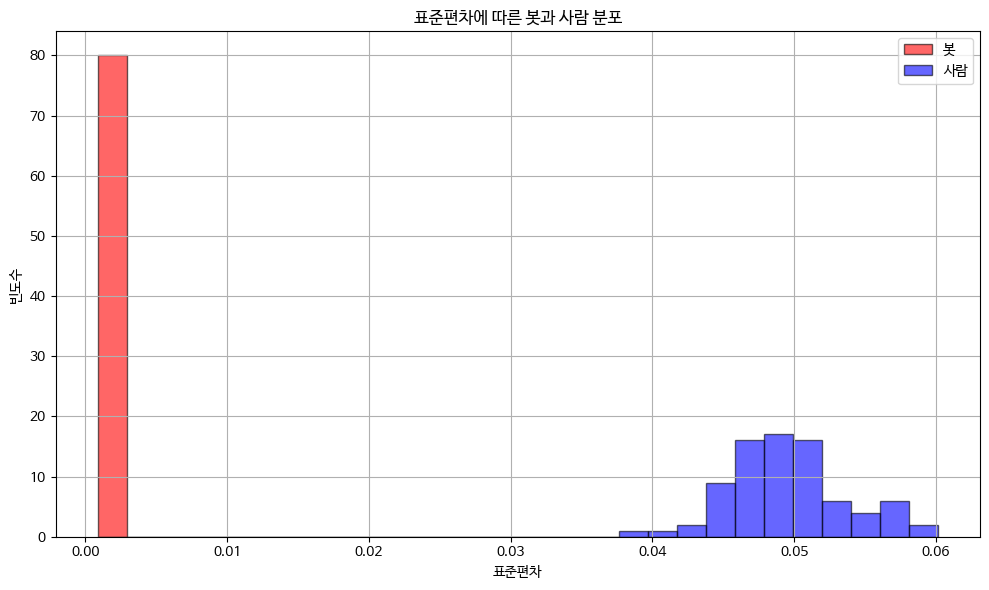

✅ 시각화 완료


In [61]:
#-----------------실행 파트-------------------
if __name__=="__main__":
  # 환경 설정
  # setup_korean_font()
  setup_font()
  # 데이터 셋 구축 (Numpy 2차원 배열 (160, 103))
  numpy_dataset = build_bot_detection_dataset()
  # 넘파이 2차원 배열 기반 시각화
  visualize_dataset(numpy_dataset)